**objective**: test the numerically modelled compaction-driven excess pore pressure in PyBasin against the analytical solution of Gibson (1958)

Gibson (1958) gives the governing equation for the excess pore pressure $u(z, t)$ in a clay layer growing in thickness at a constant rate $m$ on an impervious base, with elevation $z$ measured from the base:

$$c_v \frac{\partial^2 u}{\partial z^2} = \frac{\partial u}{\partial t} - \gamma' \frac{\mathrm{d}h}{\mathrm{d}t}$$

where $c_v$ is the consolidation coefficient, $h(t) = m t$ is the current layer thickness and $\gamma'$ is the submerged unit weight of the solids. With a pervious top ($u = 0$ at $z = h$) and a no-flow base ($\partial u / \partial z = 0$ at $z = 0$), the solution is:

$$u(z,t) = \gamma' m t - \gamma' (\pi c_v t)^{-1/2} \int_0^\infty \xi \tanh\!\left(\frac{m \xi}{2 c_v}\right) \cosh\!\left(\frac{z \xi}{2 c_v t}\right) \exp\!\left(\frac{-\xi^2}{4 c_v t}\right) \mathrm{d}\xi$$

The integral is evaluated below by numerical quadrature, using the image-source identity

$$\exp\!\left(\frac{-z^2}{4 c_v t}\right) \cosh\!\left(\frac{z \xi}{2 c_v t}\right) \exp\!\left(\frac{-\xi^2}{4 c_v t}\right) = \frac{1}{2}\left[\exp\!\left(\frac{-(z-\xi)^2}{4 c_v t}\right) + \exp\!\left(\frac{-(z+\xi)^2}{4 c_v t}\right)\right]$$

which keeps the integrand bounded (the literal $\cosh$ term overflows for large $\xi$) and folds the leading $\exp(-z^2/4c_vt)$ prefactor into the integral.

This is the same benchmark as `tests/test_compaction.py::test_gibson_transient_solution` and the model-verification section of the PyBasin manuscript (`manuscript/pybasin_manuscript_outline.tex`); the figure produced at the end of this notebook is saved to `manuscript/fig/compaction_benchmark`, the same file used there.

## Import modules

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as pl
from scipy.integrate import quad

# add the repository root to the path so the model library can be imported
repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from lib import pybasin_lib

## Set up the model parameters

In [2]:
# seconds per year
yr = 365.25 * 24 * 3600.0

# constant porosity, so the buoyant unit weight and consolidation
# coefficient are also constant, matching Gibson's linear theory
phi_o = 0.4
rho_grain = 2650.0
rho_f = 1000.0
compressibility_stress = 1.0e-3
gamma_prime = (1.0 - phi_o) * (rho_grain - rho_f) * pybasin_lib.G_ACCEL

# final column thickness and total deposition time
total_depth = 1000.0
total_time = 10.0e6 * yr
n_layers = 300
dz = total_depth / n_layers
dt = total_time / n_layers
m = dz / dt

# specific storage with the elastic terms at zero, and permeability
# chosen to give a consolidation time factor cv * t / H^2 of order 1,
# ie. an intermediate regime where neither drainage nor storage
# dominates
specific_storage = compressibility_stress * phi_o
time_factor = 1.0
cv = time_factor * total_depth ** 2 / total_time
viscosity = 1.0e-3
permeability = cv * specific_storage * viscosity

## Run the PyBasin numerical compaction model

The column grows by depositing one node at the surface every timestep and burying every previously deposited node by one grid spacing, so that every node accumulates load continuously, matching the assumption behind Gibson's equation. This uses the same loading (`cumulative_buoyant_stress`), storage (`compaction_storage`) and solver (`solve_1D_pore_pressure`) functions that `run_burial_hist_model` in `lib/pybasin_lib.py` uses.

In [3]:
def run_growing_column(n_layers, dz, dt, phi_o, permeability, viscosity,
                       rho_grain, rho_f, compressibility_stress):

    # the elastic skeleton and pore water compressibilities are fixed
    # at zero, so compaction_storage() returns a purely
    # compaction-driven storage term, ie. the single linear
    # compressibility Gibson's theory assumes
    alpha_skeleton = 0.0
    beta_water = 0.0

    depths = np.array([0.0])
    P_ex = np.array([0.0])
    sigma_buoyant_prev = np.array([0.0])
    sigma_eff_max_prev = np.array([0.0])

    for _ in range(n_layers):

        # deposit a new node at the surface and bury every existing
        # node by one grid spacing
        depths = np.concatenate(([0.0], depths + dz))
        P_ex = np.concatenate(([0.0], P_ex))
        sigma_buoyant_prev = np.concatenate(([0.0], sigma_buoyant_prev))
        sigma_eff_max_prev = np.concatenate(([0.0], sigma_eff_max_prev))

        phi = np.full_like(depths, phi_o)
        rho_bulk = rho_grain * (1.0 - phi) + rho_f * phi

        sigma_buoyant = pybasin_lib.cumulative_buoyant_stress(
            depths, rho_bulk, rho_f)
        loading_rate = (sigma_buoyant - sigma_buoyant_prev) / dt

        sigma_eff = np.clip(sigma_buoyant - P_ex, 0.0, None)

        storage_elastic, is_virgin = pybasin_lib.compaction_storage(
            phi, sigma_eff, sigma_eff_max_prev, alpha_skeleton, beta_water)

        c_sigma = np.full_like(phi, compressibility_stress)
        dphi_dsigma_eff = np.where(is_virgin, -c_sigma * phi, 0.0)

        Q = -dphi_dsigma_eff * loading_rate
        storage = storage_elastic - dphi_dsigma_eff

        K_hydraulic = np.full(len(depths) - 1, permeability / viscosity)

        P_ex, _ = pybasin_lib.solve_1D_pore_pressure(
            P_ex, depths, dt, K_hydraulic, storage, Q,
            None, 0.0, 0.0, None)

        sigma_buoyant_prev = sigma_buoyant
        sigma_eff_post = np.clip(sigma_buoyant - P_ex, 0.0, None)
        sigma_eff_max_prev = np.maximum(sigma_eff_post, sigma_eff_max_prev)

    return depths, P_ex


depths, P_ex_pybasin = run_growing_column(
    n_layers, dz, dt, phi_o, permeability, viscosity,
    rho_grain, rho_f, compressibility_stress)

## Gibson's (1958) exact solution

In [4]:
def gibson_excess_pressure(z, t, m, cv, gamma_prime, xi_limit_factor=40.0):

    xi_limit = (xi_limit_factor * np.sqrt(4.0 * cv * t)
               + 20.0 * cv / m)

    def integrand(xi):
        tanh_term = np.tanh(m * xi / (2.0 * cv))
        image_pair = 0.5 * (np.exp(-(z - xi) ** 2 / (4.0 * cv * t))
                            + np.exp(-(z + xi) ** 2 / (4.0 * cv * t)))
        return xi * tanh_term * image_pair

    integral, _ = quad(integrand, 0.0, xi_limit, limit=400)
    prefactor = gamma_prime * (np.pi * cv * t) ** -0.5

    return gamma_prime * m * t - prefactor * integral


# Gibson's z is elevation above the impervious base; depths is depth
# below the pervious surface, so z = total_depth - depth
z_gibson = total_depth - depths
P_ex_gibson = np.array([
    gibson_excess_pressure(z, total_time, m, cv, gamma_prime)
    for z in z_gibson])

## Compare the numerical and analytical solutions

The figure below is saved to `manuscript/fig/compaction_benchmark`, the same figure used in the PyBasin manuscript.

consolidation time factor cv * t / H^2: 1.00
maximum absolute difference PyBasin vs Gibson (1958): 8.109e+03 Pa
maximum relative difference: 0.0031


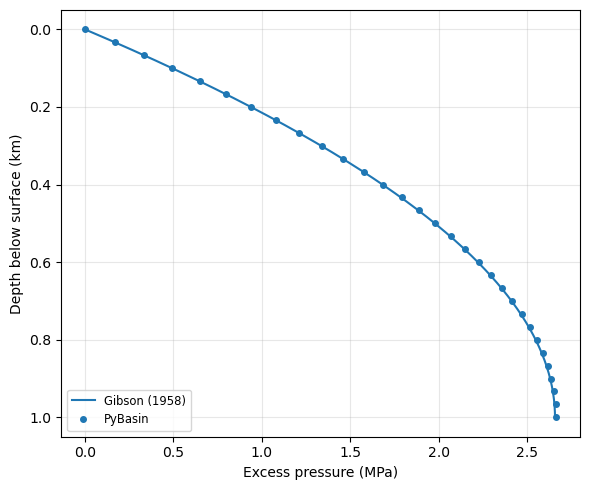

In [5]:
order = np.argsort(depths)
depths_sorted = depths[order]
P_ex_pybasin_sorted = P_ex_pybasin[order]
P_ex_gibson_sorted = P_ex_gibson[order]

max_error = np.max(np.abs(P_ex_pybasin_sorted - P_ex_gibson_sorted))
max_error_relative = max_error / np.max(np.abs(P_ex_gibson_sorted))

fig, ax = pl.subplots(1, 1, figsize=(6, 5))

ax.plot(P_ex_gibson_sorted / 1.0e6, depths_sorted / 1000.0,
       color='C0', lw=1.5, label='Gibson (1958)')
ax.plot(P_ex_pybasin_sorted / 1.0e6, depths_sorted / 1000.0,
       color='C0', lw=0, marker='o', markersize=4, markevery=10,
       label='PyBasin')

ax.invert_yaxis()
ax.set_xlabel('Excess pressure (MPa)')
ax.set_ylabel('Depth below surface (km)')
ax.legend(fontsize='small', loc='lower left')
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig_dir = os.path.join(repo_root, 'manuscript', 'fig')
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)

fig_fn = os.path.join(fig_dir, 'compaction_benchmark')
fig.savefig(fig_fn + '.pdf')
fig.savefig(fig_fn + '.png', dpi=200)

print('consolidation time factor cv * t / H^2: %0.2f' % time_factor)
print('maximum absolute difference PyBasin vs Gibson (1958): %0.3e Pa'
     % max_error)
print('maximum relative difference: %0.4f' % max_error_relative)